<a href="https://colab.research.google.com/github/ZidAvwa/PCVK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from google.colab.patches import cv2_imshow
import glob
import math

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Tugas Praktikum**

---

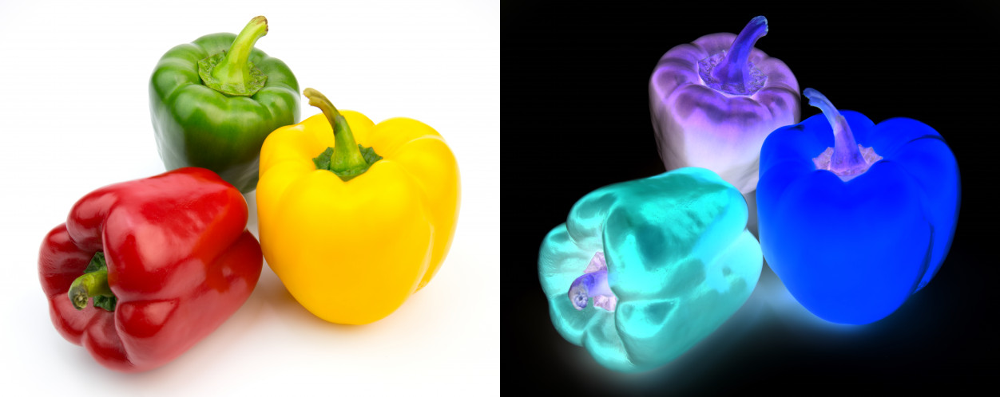

In [10]:
original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/peppers.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


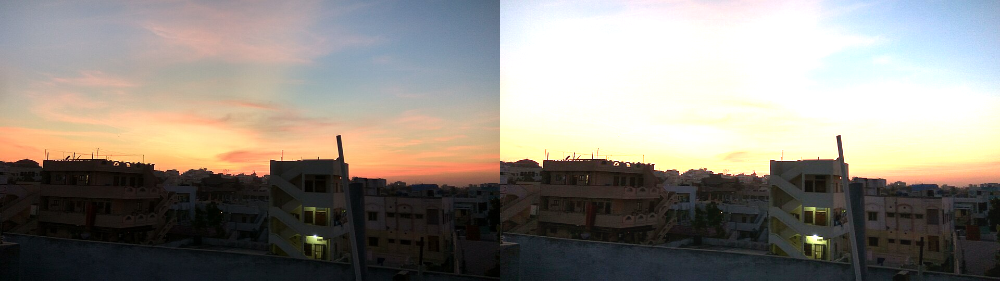

In [11]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-' * 50)
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(contrast * original[y, x, c] + brightness, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra 
--------------------------
Masukkan nilai kecerahan: 30


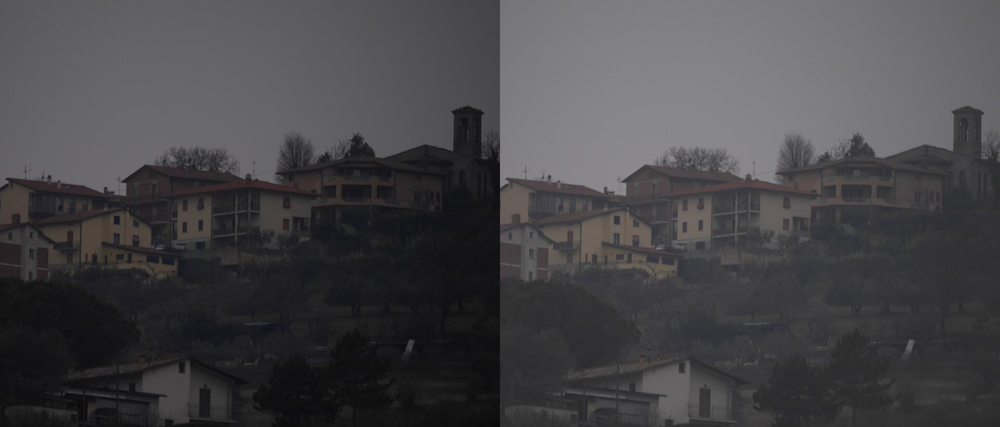

In [8]:
print(' Mengubah tingkat kecerahan citra ')
print('--------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

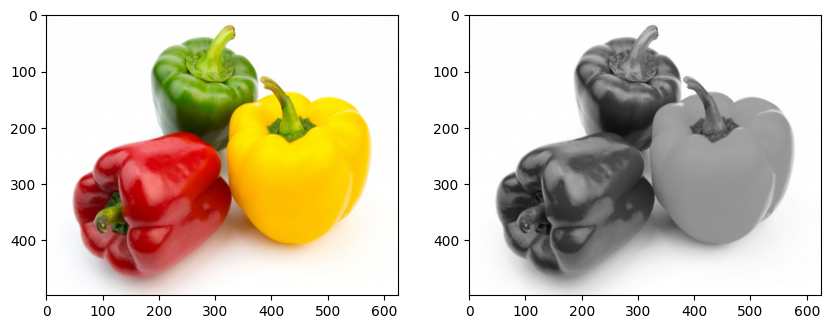

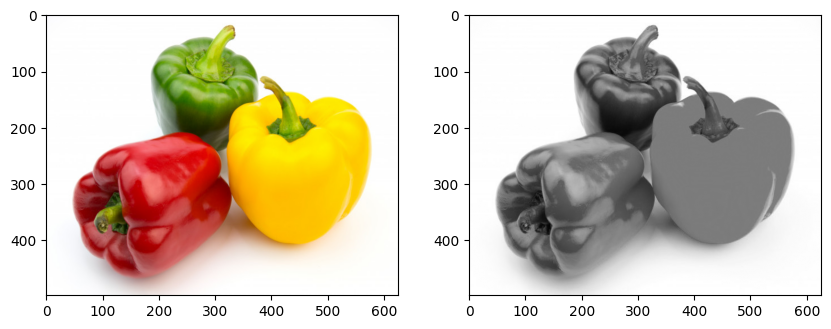

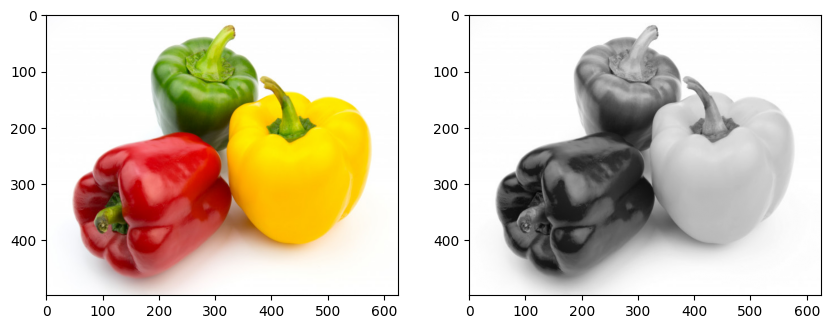

In [12]:
img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

img_avg = ((R + G + B) / 3).astype(np.uint8)

img_light = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

img_lum = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[1].imshow(img_avg, cmap='gray')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[1].imshow(img_light, cmap='gray')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[1].imshow(img_lum, cmap='gray')
plt.show()

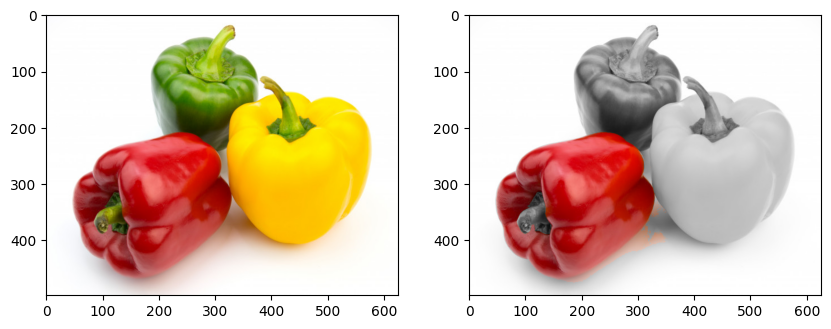

In [13]:
img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 50, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
mask = mask1 | mask2

img_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
img_gray_3c = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)

img_result = np.where(mask[:, :, None] == 255, img_rgb, img_gray_3c)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[1].imshow(img_result)
plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


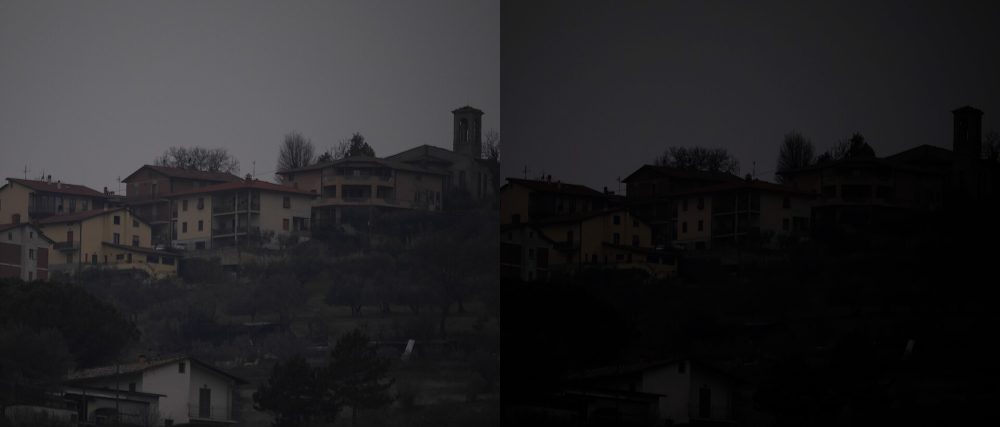

In [15]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/houses.jpg')
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            gamma_image[y, x, c] = np.clip(255 * (original[y, x, c] / 255.0) ** (1 / gamma), 0, 255)

final_frame = cv.hconcat((original, gamma_image))
cv2_imshow(final_frame)

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


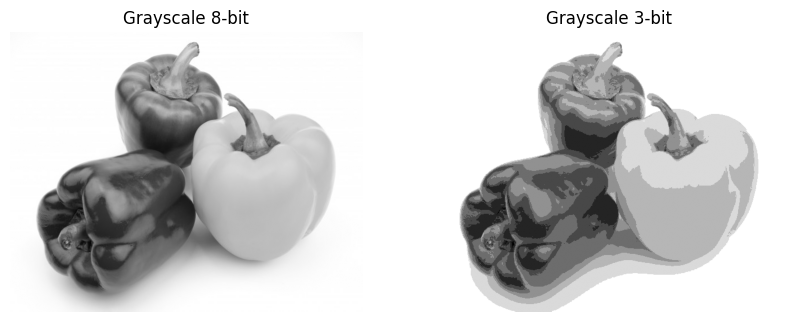

In [17]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

print('Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

level = 255.0 / (pow(2, bit_depth) - 1)
original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = np.round(original[y, x] / level) * level

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Grayscale 8-bit')
axes[0].axis('off')

axes[1].imshow(depth_image, cmap='gray')
axes[1].set_title(f'Grayscale {bit_depth}-bit')
axes[1].axis('off')

plt.show()

Jumlah Citra di Average: 10 | Nilai PSNR (dB): 19.7286


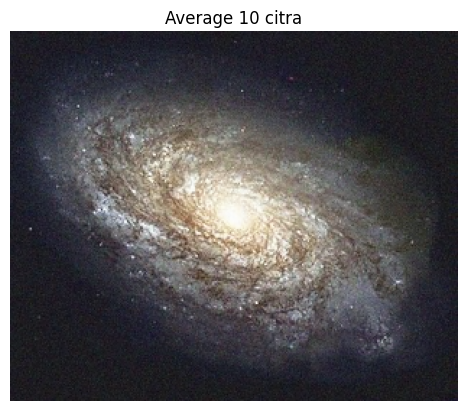

Jumlah Citra di Average: 20 | Nilai PSNR (dB): 19.8343


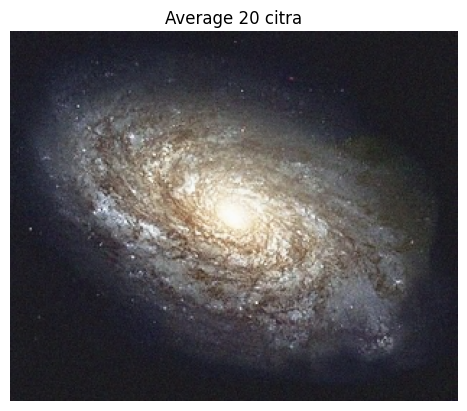

Jumlah Citra di Average: 40 | Nilai PSNR (dB): 19.8885


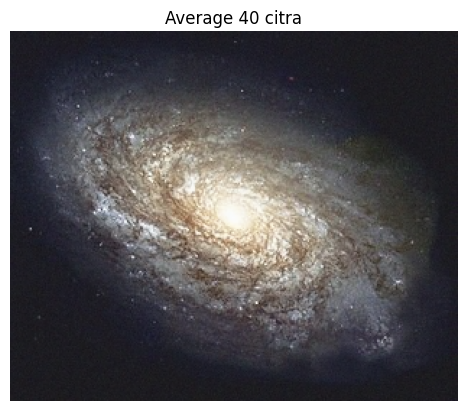

Jumlah Citra di Average: 80 | Nilai PSNR (dB): 19.9179


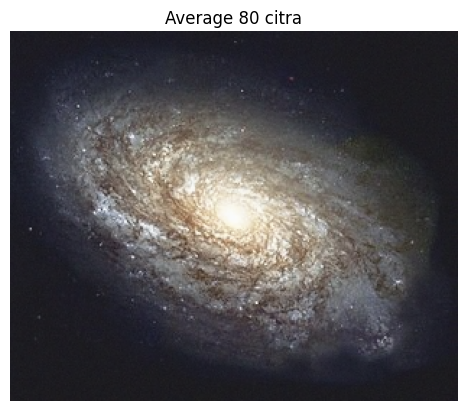

Jumlah Citra di Average: 100 | Nilai PSNR (dB): 19.9220


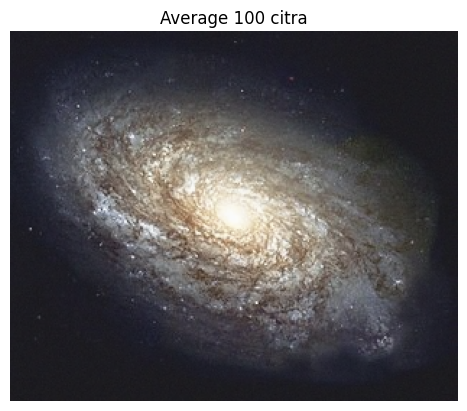

In [20]:
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    max_pixel = 255.0
    psnr_val = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr_val

original = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/galaxy.jpg')

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK Semester 5/Images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

counts = [10, 20, 40, 80, 100]

for count in counts:
    if count > len(cv_img):
        break

    avg_img = np.zeros(original.shape, np.float64)
    for i in range(count):
        avg_img += cv_img[i]

    avg_img = (avg_img / count).astype(np.uint8)

    psnr_value = calculate_psnr(original, avg_img)
    print(f"Jumlah Citra di Average: {count} | Nilai PSNR (dB): {psnr_value:.4f}")

    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    plt.title(f"Average {count} citra")
    plt.axis('off')
    plt.show()

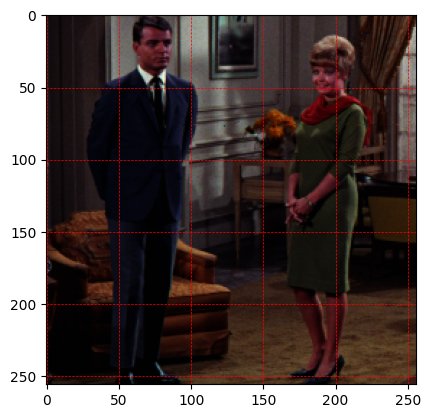

In [28]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/couple.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.grid(True, color='red', linestyle='--', linewidth=0.5)
plt.show()

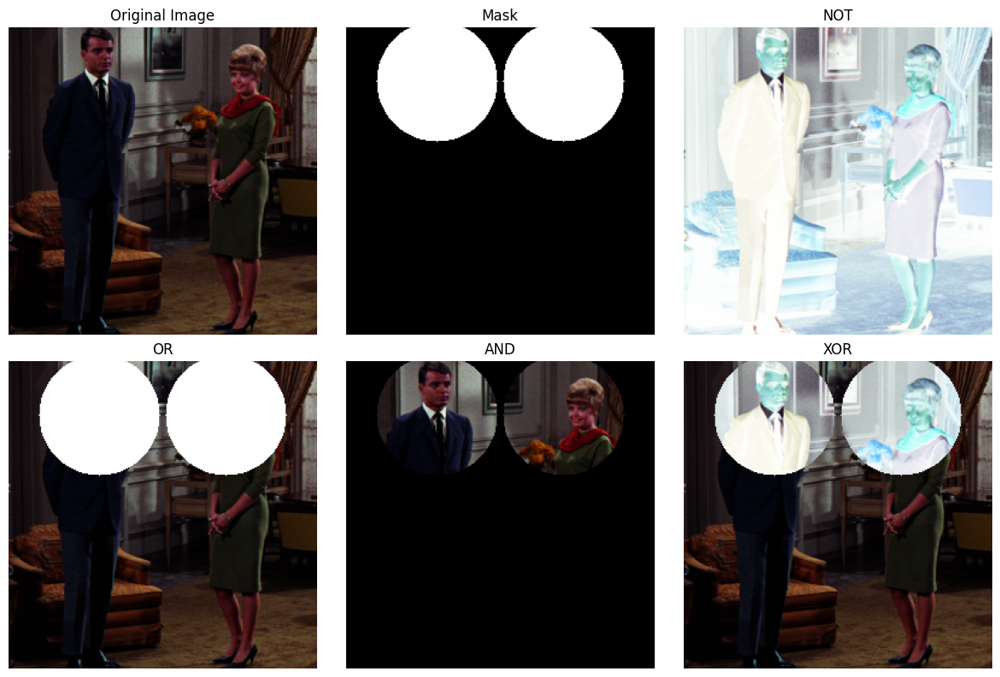

In [30]:
img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/couple.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

mask = np.zeros(img_rgb.shape, dtype=np.uint8)

cv.circle(mask, (75, 45), 50, (255, 255, 255), -1)
cv.circle(mask, (180, 45), 50, (255, 255, 255), -1)

img_not = cv.bitwise_not(img_rgb)
img_or = cv.bitwise_or(img_rgb, mask)
img_and = cv.bitwise_and(img_rgb, mask)
img_xor = cv.bitwise_xor(img_rgb, mask)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 1].imshow(mask)
axes[0, 1].set_title('Mask')
axes[0, 2].imshow(img_not)
axes[0, 2].set_title('NOT')
axes[1, 0].imshow(img_or)
axes[1, 0].set_title('OR')
axes[1, 1].imshow(img_and)
axes[1, 1].set_title('AND')
axes[1, 2].imshow(img_xor)
axes[1, 2].set_title('XOR')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

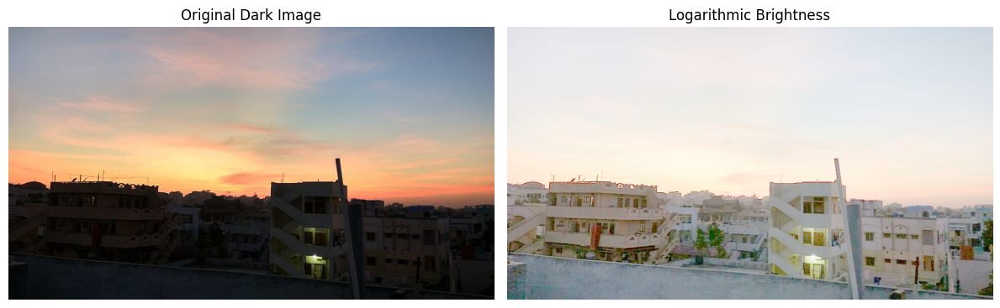

In [31]:
img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/sunset.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

c = 255 / np.log(1 + 255)

log_image = c * (np.log(1 + img_rgb.astype(np.float32)))
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Dark Image')
axes[1].imshow(log_image)
axes[1].set_title('Logarithmic Brightness')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

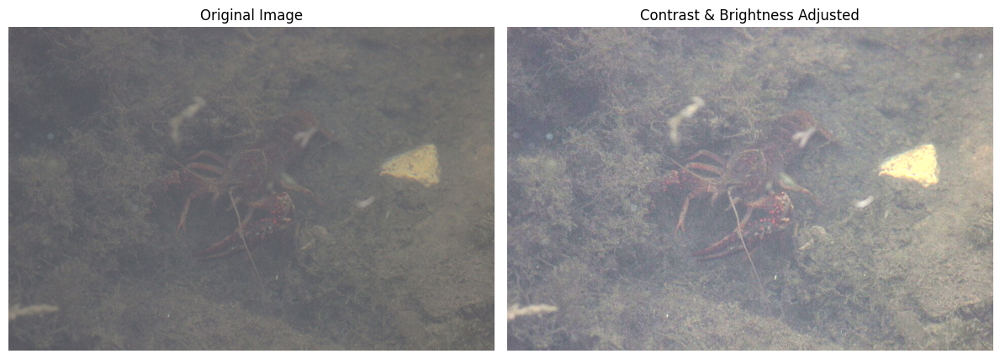

In [32]:
img = cv.imread('/content/drive/MyDrive/PCVK Semester 5/Images/crayfish.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

a = 2.0
b = -70

result_image = np.clip(a * img_rgb.astype(np.float32) + b, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[1].imshow(result_image)
axes[1].set_title('Contrast & Brightness Adjusted')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()